<a href="https://colab.research.google.com/github/databyhuseyn/DeepLearning/blob/main/Building_Inception_using_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch.nn as nn
import torch
import torch.nn.functional as F

In [2]:
class InceptionBlock(nn.Module):
  def __init__(self, in_channel, c1,
               c3_reduce, c3,
               c5_reduce, c5,
               out_pool):
    super().__init__()

    # branch 1
    self.c1 = nn.Conv2d(in_channel, c1, 1, padding='same')

    # branch 2
    self.c2 = nn.Sequential(
              nn.Conv2d(in_channel, c3_reduce, 1, padding='same'),
              nn.ReLU(),
              nn.Conv2d(c3_reduce, c3, 3, padding=1))
    # branch 3
    self.c3 = nn.Sequential(
              nn.Conv2d(in_channel, c5_reduce, 1, padding='same'),
              nn.ReLU(),
              nn.Conv2d(c5_reduce, c5, 5, padding=2))

    # branch 4
    self.c4 = nn.Sequential(
        nn.MaxPool2d(3, 1, 1),
        nn.Conv2d(in_channel, out_pool, 1, padding='same')
    )

  def forward(self, X):
    out1 = F.relu(self.c1(X))
    out2 = F.relu(self.c2(X))
    out3 = F.relu(self.c3(X))
    out4 = F.relu(self.c4(X))

    return torch.concat([out1, out2, out3, out4], dim=1)

In [3]:
class InceptionNet(nn.Module):
  def __init__(self, in_channels, n_classes: int=10):   #aux1, aux2,
    super().__init__()

    # conv 1
    self.conv1 = nn.Conv2d(in_channels, 64, 7, stride=2, padding=3 )
    self.pool1 = nn.MaxPool2d(3, 2)

    # conv 2
    self.conv2 = nn.Sequential(
    nn.Conv2d(64, 64, 1),
    nn.ReLU(),
    nn.Conv2d(64, 192, 3, padding=1)
    )
    self.pool2 = nn.MaxPool2d(3, 2, )

    # inception 1
    self.inception_3a = InceptionBlock(192, 64, 96, 128, 16, 32, 32)
    self.inception_3b = InceptionBlock(256, 128, 128, 192, 32, 96, 64) ### 224

    # pool 3
    self.pool3 = nn.MaxPool2d(3, 2, )

    # inception 2
    self.inception_4a = InceptionBlock(480, 192, 96, 208, 16, 48, 64)
    self.inception_4b = InceptionBlock(512, 160, 112, 224, 24, 64, 64)
    self.inception_4c = InceptionBlock(512, 128, 128, 256, 24, 64, 64)
    self.inception_4d = InceptionBlock(512, 112, 144, 288, 32, 64, 64)
    self.inception_4e = InceptionBlock(528, 256, 160, 320, 32, 128, 128)

    # pool 4
    self.pool4 = nn.MaxPool2d(3, 2, )

    # inception 3
    self.inception_5a = InceptionBlock(832, 256, 160, 320, 32, 128, 128)
    self.inception_5b = InceptionBlock(832, 384, 192, 384, 48, 128, 128)

    # average pool 1
    self.avg_pool1 = nn.AdaptiveAvgPool2d((1,1))
    self.dropout = nn.Dropout(0.4)

    # outputs
    self.main_output = nn.Linear(1024, n_classes)
    # self.aux_output1 = nn.Sequential(
    #     nn.AvgPool2d(5, 3),
    #     nn.Conv2d(aux1, 256, 1, ),
    #     nn.ReLU(),
    #     nn.AvgP

    # )

  def forward(self, X):
    x = F.relu(self.conv1(X))
    x = self.pool1(x)

    x = F.relu(self.conv2(x))
    x = self.pool2(x)

    # inception 1
    x = self.inception_3a(x)
    x = self.inception_3b(x)

    x = self.pool3(x)

    # inception 2
    x = self.inception_4a(x)
    x = self.inception_4b(x)
    x = self.inception_4c(x)
    x = self.inception_4d(x)
    x = self.inception_4e(x)

    x = self.pool4(x)

    # inception 3

    x = self.inception_5a(x)
    x = self.inception_5b(x)

    # avg pool
    x = self.avg_pool1(x)
    x = torch.flatten(x, 1)
    x = self.dropout(x)
    x = self.main_output(x)

    return x


In [4]:
model = InceptionNet(3, 1)

In [5]:
!curl -L -o fracture-multi-region-x-ray-data.zip https://www.kaggle.com/api/v1/datasets/download/bmadushanirodrigo/fracture-multi-region-x-ray-data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  481M  100  481M    0     0   145M      0  0:00:03  0:00:03 --:--:--  182M


In [6]:
!unzip fracture-multi-region-x-ray-data.zip

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated3 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Class

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [9]:
dataset = datasets.ImageFolder(
    root = '/content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train',
    transform=transform
)

In [10]:
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [11]:
dataset.classes

['fractured', 'not fractured']

In [12]:
if torch.cuda.is_available():
  device = 'cuda'
elif torch.backends.mps.is_available():
  device = 'mps'
else:
  device = 'cpu'

In [13]:
device

'cuda'

In [14]:
import matplotlib.pyplot as plt

In [15]:
A, B = next(iter(train_loader))

In [16]:
A.shape

torch.Size([32, 3, 224, 224])

In [17]:
B.shape

torch.Size([32])

In [22]:
def train_inception(model, criterion, optimizer, data_loader, n_epochs, plot=False):
  losses = [] # Initialize losses list here
  for epoch in range(n_epochs):
    total_loss = 0.
    for images, labels in data_loader:
      images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
      pred_labels = model(images)
      loss = criterion(pred_labels, labels)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    mean_loss = total_loss / len(train_loader)
    losses.append(mean_loss)

    print(f'Epoch: {epoch+1}/{n_epochs}, Loss: {mean_loss}')

  if plot:
    plt.title('Loss Curve')
    plt.plot(range(n_epochs), losses)
    plt.show()

In [23]:
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
train_inception(model, criterion, optimizer, train_loader, 20, True)

Epoch: 1/20, Loss: 0.6932571734524103
Epoch: 2/20, Loss: 0.6932904753305508
Epoch: 3/20, Loss: 0.6934314976514004
Epoch: 4/20, Loss: 0.6933480284618259
Epoch: 5/20, Loss: 0.6932384142826172
Epoch: 6/20, Loss: 0.69321909309671


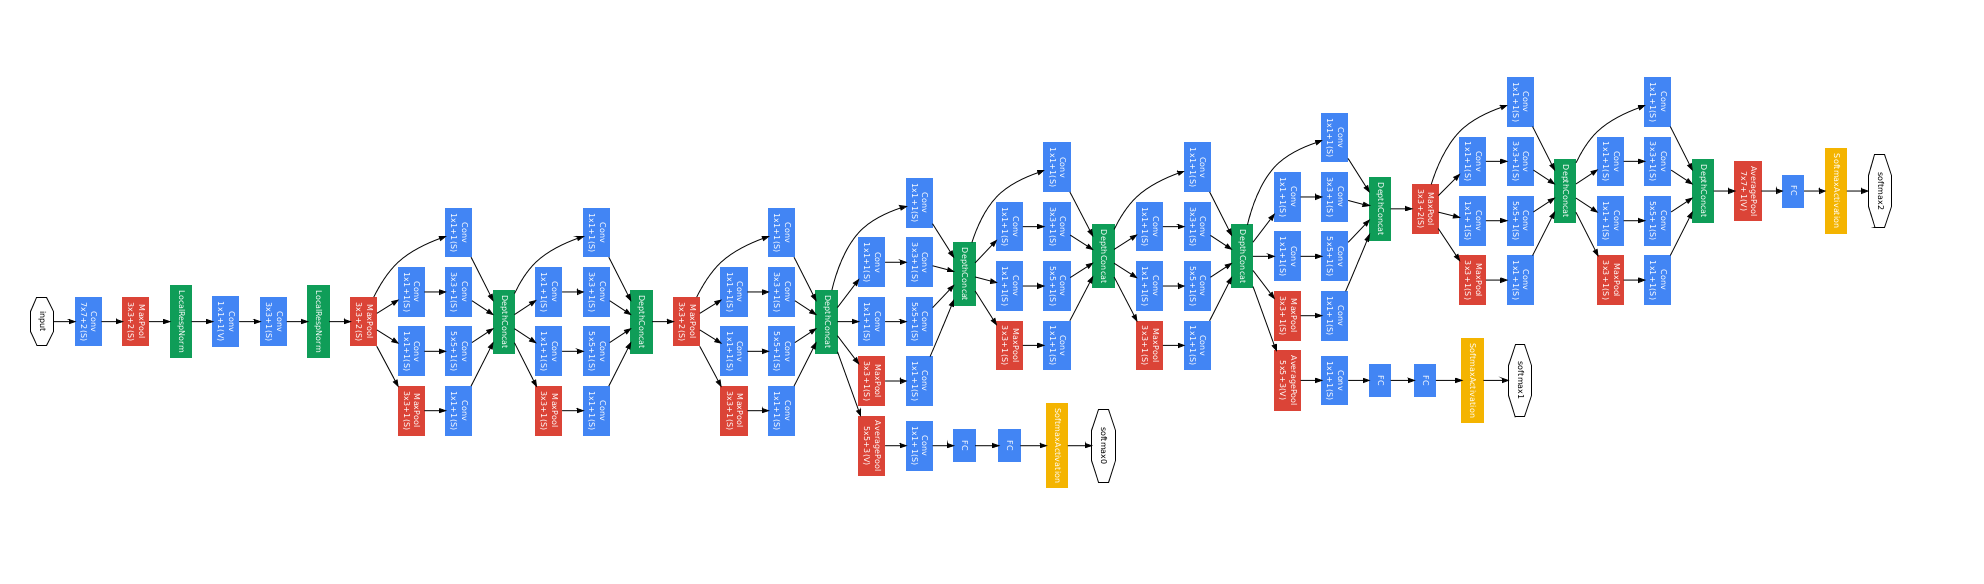

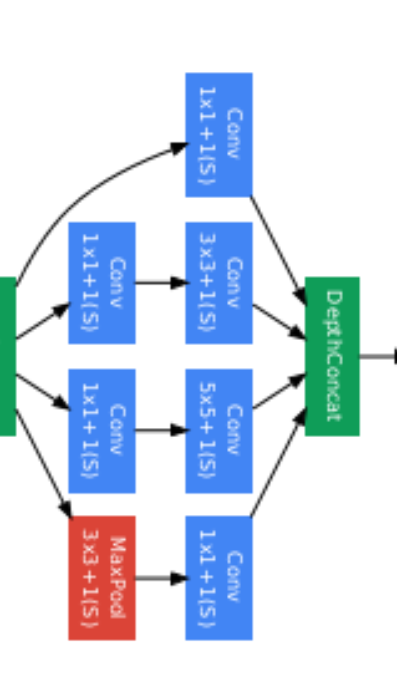